# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, MemoryDataset, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog
from inspect_ai.model import get_model

import os

In [2]:
MODEL_A = get_model("vllm/qwen3-30b",  base_url="http://localhost:8001/v1")
MODEL_B = get_model("vllm/qwen3.5-35b", base_url="http://localhost:8000/v1")

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [5]:
#had to download the dataset manually


MMLU_PATH = "mmlu_all_test.parquet"   

_df_raw = pd.read_parquet(MMLU_PATH)

dataset_raw = MemoryDataset([
    Sample(
        input=row["question"],
        target=str(row["answer"]),
        metadata={"choices": row["choices"], "subject": row["subject"]},
    )
    for _, row in _df_raw.iterrows()
], name="mmlu")

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0' '4' '2' '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [6]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = MemoryDataset([
    record_to_sample(row.to_dict()) for _, row in _df_raw.iterrows()
], name="mmlu")

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [32]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")


MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") ==  "college_mathematics")

print(f"My subset: {len(MY_SUBSET)} questions")

Astronomy: 152 questions
My subset: 100 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [8]:
from inspect_ai.model import GenerateConfig

@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice(),
        config=GenerateConfig(temperature=0.3)
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [9]:
logs: List[EvalLog] = eval(
    mmlu_subset(astronomy_subset),
    model=MODEL_A,
    display="plain",
    limit=10        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

---------------------------------------------------------
mmlu_subset (10 samples): vllm/qwen3-30b                 
temperature: 0.3, subset: mmlu, dataset: mmlu            
---------------------------------------------------------

Steps:  10/10 100% | Samples:  10/ 10 | accuracy: 1.00 | vllm:  0/10 | HTTP retries: 0



---------------------------------------------------------                  
mmlu_subset (10 samples): vllm/qwen3-30b                                   
temperature: 0.3, subset: mmlu, dataset: mmlu                              
                                                                           
total time:              0:00:01                                           
vllm/qwen3-30b           1,348 tokens [I: 1,298, O: 50]                    
choice                                                                     
accuracy  1.000                                                            
stderr    0.000                                                            
Log: logs/2026-03-29T08-41-55-00-00_mmlu-subset_KAkHfFJaPBaqqHXVW9TFcM.eval
---------------------------------------------------------

Status  : success
Model   : vllm/qwen3-30b
Accuracy: 1.0


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [10]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    # YOUR CODE HERE

    rows = []
    for s in log.samples:
        score_obj = s.scores["choice"]
        rows.append({
            "id": s.id,
            "epoch": s.epoch,
            "score": 1 if score_obj.value == "C" else 0,
            "subject": s.metadata.get("subject"),
        })
    return pd.DataFrame(rows)
    raise NotImplementedError

# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

   id  epoch  score    subject
0   1      1      1  astronomy
1   2      1      1  astronomy
2   3      1      1  astronomy
3   4      1      1  astronomy
4   5      1      1  astronomy

Accuracy: 100.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [11]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    accuracy = scores.mean()
    stderr = scores.std() / np.sqrt(len(scores))
    ci_low = accuracy - stderr * stats.norm.ppf((1 + ci) / 2)
    ci_high = accuracy + stderr * stats.norm.ppf((1 + ci) / 2)
    return ci_low, accuracy, ci_high


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    question_means = df.groupby("id")["score"].mean()
    return ci_accuracy_basic(question_means.values, ci)


In [12]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.223  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


In [36]:
logs: List[EvalLog] = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
    display="plain",
    epochs=10
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

---------------------------------------------------------                                                          
mmlu_subset (100 x 10 samples): vllm/qwen3-30b                                                                     
temperature: 0.3, epochs: 10, log_realtime: False, log_buffer: 100, score_display: False, subset: mmlu, dataset:   
mmlu                                                                                                               
---------------------------------------------------------

Steps:  96/1000   9% | Samples:  96/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 128/1000  12% | Samples: 128/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 202/1000  20% | Samples: 202/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 231/1000  23% | Samples: 231/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 295/1000  29% | Samples: 295/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 313/1000  31% | Samples: 313/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 351/1000  35% | Samples: 351/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 413/1000  41% | Samples: 413/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 452/1000  45% | Samples: 452/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 498/1000  49% | Samples: 498/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 528/1000  52% | Samples: 528/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 590/1000  59% | Samples: 590/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 618/1000  61% | Samples: 618/1000 | vllm:  9/10 | HTTP retries: 0
Steps: 677/1000  67% | Samples: 677/1000 | vllm:  9

---------------------------------------------------------                                                          
mmlu_subset (100 x 10 samples): vllm/qwen3-30b                                                                     
temperature: 0.3, epochs: 10, log_realtime: False, log_buffer: 100, score_display: False, subset: mmlu, dataset:   
mmlu                                                                                                               
                                                                                                                   
total time:                     0:02:21                                                                            
vllm/qwen3-30b                  221,294 tokens [I: 128,000, O: 93,294]                                             
choice                                                                                                             
accuracy  0.777                                                                                                    
stderr    0.041                                                                                                    
Log: logs/2026-03-29T09-06-01-00-00_mmlu-subset_i9fGGxBPpPvFQGUDvLjWa4.eval                                        
---------------------------------------------------------

Status  : success
Model   : vllm/qwen3-30b
Accuracy: 0.777


In [47]:
df_k = log_to_df(log)

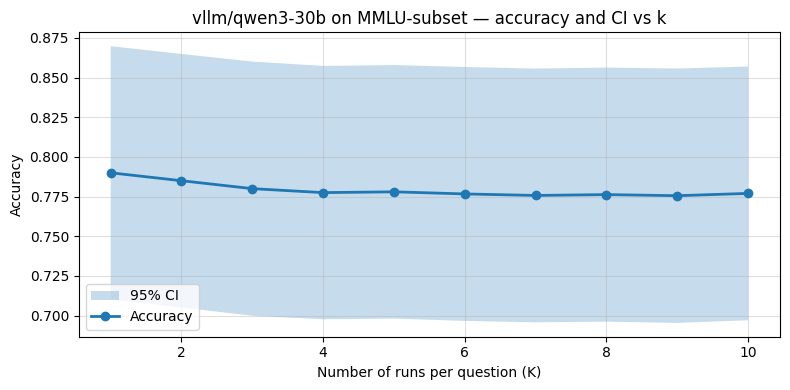

In [48]:
k_values    = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
accuracies  = []
ci_lowers   = []
ci_uppers   = []
for k in k_values:
    subset_df = df_k[df_k['epoch'] <= k]
    ci_low, accuracy, ci_high = ci_accuracy(subset_df)
    accuracies.append(accuracy)
    ci_lowers.append(ci_low)
    ci_uppers.append(ci_high)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**

- band doesn't actually narrows - it says that the model pretty much has consistennt answers over runs - so we really dont need to allocate a lot of budget over multiple 

And here are the questions that are consistently wrong

In [52]:
df_errors = log_to_df(log)
log_samples = log.samples

q_scores = df_errors.groupby("id").agg(
    mean_score=("score", "mean"),
    n_epochs=("score", "count"),
    subject=("subject", "first"),
).sort_values("mean_score")

always_wrong = q_scores[q_scores["mean_score"] == 0]
print(f"Consistently wrong: {len(always_wrong)} / {len(q_scores)} questions\n")

for qid, row in always_wrong.iterrows():
    sample = [s for s in MY_SUBSET if s.id == qid][0]
    # Get model answers across all epochs for this question
    model_answers = [
        s.scores["choice"].answer
        for s in log_samples if s.id == qid
    ]
    correct_idx = ord(sample.target) - ord("A")
    print(f"Q{qid} [{row['subject']}]")
    print(f"  {sample.input[:150]}")
    for i, ch in enumerate(sample.choices):
        marker = " <-- correct" if i == correct_idx else ""
        print(f"    {chr(65+i)}) {ch}{marker}")
    print(f"  Model answered: {model_answers}")
    print()

Consistently wrong: 21 / 100 questions

Q2 [college_mathematics]
  Up to isomorphism, how many additive abelian groups G of order 16 have the property that x + x + x + x = 0 for each x in G ?
    A) 0
    B) 1
    C) 2
    D) 3 <-- correct
  Model answered: ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C']

Q3 [college_mathematics]
  Suppose P is the set of polynomials with coefficients in Z_5 and degree less than or equal to 7. If the operator D sends p(x) in P to its derivative p
    A) n = 1 and r = 6
    B) n = 1 and r = 7
    C) n = 2 and r = 5
    D) n = 2 and r = 6 <-- correct
  Model answered: ['B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B']

Q16 [college_mathematics]
  Let K be a nonempty subset of R^n, where n > 1. Which of the following statements must be true?
I. If K is compact, then every continuous real-valued 
    A) I only
    B) II only
    C) III only
    D) I and II only <-- correct
  Model answered: ['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A']

Q10 [colleg

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

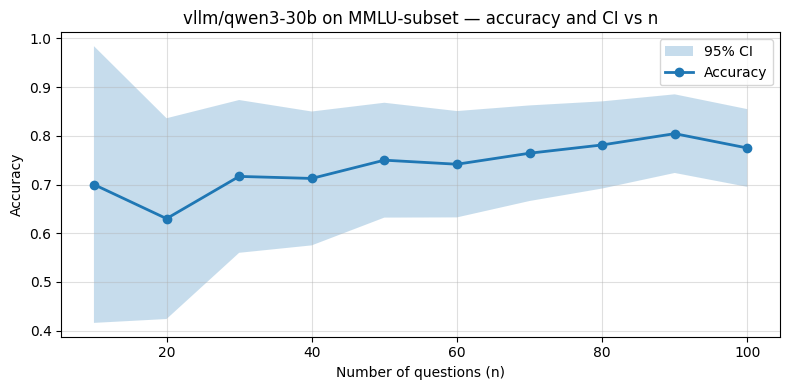

In [21]:
question_ids  = df_k["id"].unique()
dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies    = []
ci_lowers     = []
ci_uppers     = []

for n in dataset_sizes:
    subset_df = df_k[df_k["id"].isin(question_ids[:n])]
    ci_low, accuracy, ci_high = ci_accuracy(subset_df)
    accuracies.append(accuracy)
    ci_lowers.append(ci_low)
    ci_uppers.append(ci_high)

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**
- line sabilizes at about 60 questions - that is more than a half of a dataset. And line actually converges to a level of accuracy we see,  there is a subset of questions that are too complex for a given model or just mislabeled - and by taking more questons we take all subset into account

## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [22]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"
    
    alternative = "two-sided" if two_tailed else "greater"
    
    _, p_value  = stats.ttest_rel(scores1, scores2, alternative=alternative)
    mean_diff   = (scores1 - scores2).mean()
    
    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [23]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


/opt/matcher/envs/vllm_inference/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [24]:
p_val, mean_diff, is_sig = compare_models_paired(
    MODEL_A,
    MODEL_B,
    MY_SUBSET,
)
print(f"p-value:         {p_val:.4f}")
print(f"mean diff (A-B): {mean_diff:+.4f}")
print(f"significant:     {is_sig}")

  Running vllm/qwen3-30b ...


---------------------------------------------------------
mmlu_subset (100 samples): vllm/qwen3-30b                
temperature: 0.3, subset: mmlu, dataset: mmlu            
---------------------------------------------------------

Steps:  73/100  73% | Samples:  73/100 | accuracy: 0.75 | vllm:  9/10 | HTTP retries: 0
Steps:  99/100  99% | Samples:  99/100 | accuracy: 0.77 | vllm:  1/10 | HTTP retries: 0
Steps: 100/100 100% | Samples: 100/100 | accuracy: 0.78 | vllm:  0/10 | HTTP retries: 0



---------------------------------------------------------                  
mmlu_subset (100 samples): vllm/qwen3-30b                                  
temperature: 0.3, subset: mmlu, dataset: mmlu                              
                                                                           
total time:            0:00:12                                             
vllm/qwen3-30b         19,967 tokens [I: 12,800, O: 7,167]                 
choice                                                                     
accuracy  0.780                                                            
stderr    0.042                                                            
Log: logs/2026-03-29T08-48-13-00-00_mmlu-subset_DHoneJwQhZz9cRzt7nzPsL.eval
---------------------------------------------------------

  Running vllm/qwen3.5-35b ...


---------------------------------------------------------
mmlu_subset (100 samples): vllm/qwen3.5-35b              
temperature: 0.3, subset: mmlu, dataset: mmlu            
---------------------------------------------------------

Steps: 100/100 100% | Samples: 100/100 | accuracy: 0.78 | vllm:  0/10 | HTTP retries: 0



---------------------------------------------------------                  
mmlu_subset (100 samples): vllm/qwen3.5-35b                                
temperature: 0.3, subset: mmlu, dataset: mmlu                              
                                                                           
total time:               0:00:02                                          
vllm/qwen3.5-35b          13,978 tokens [I: 13,478, O: 500]                
choice                                                                     
accuracy  0.770                                                            
stderr    0.042                                                            
Log: logs/2026-03-29T08-48-25-00-00_mmlu-subset_VFSk9cJf8kV5obhvmBfMxJ.eval
---------------------------------------------------------

p-value:         0.8426
mean diff (A-B): +0.0100
significant:     False


---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:**
nope it is not  - it would not really matter - those are really close models and have basically the same knowledge - so yeah, comparing those is hard on such an old and well known dataset 

## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [27]:
def ci_accuracy_for_difference(
    model_a,
    model_b,
    dataset,
    ci: float = 0.95,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, float]:
    """95% CI on the mean per-question score difference (A - B)."""
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    diffs = scores_a - scores_b
    return ci_accuracy_basic(diffs, ci)

lo, mean_diff, hi = ci_accuracy_for_difference(MODEL_A, MODEL_B, MY_SUBSET)
print(f"Mean diff (A-B): {mean_diff:+.4f}")
print(f"95% CI:          [{lo:+.4f}, {hi:+.4f}]")
print(f"Contains zero:   {lo <= 0 <= hi}")

  Running vllm/qwen3-30b ...


---------------------------------------------------------
mmlu_subset (100 samples): vllm/qwen3-30b                
temperature: 0.3, subset: mmlu, dataset: mmlu            
---------------------------------------------------------

Steps:  85/100  85% | Samples:  85/100 | accuracy: 0.78 | vllm:  9/10 | HTTP retries: 0
Steps:  98/100  98% | Samples:  98/100 | accuracy: 0.76 | vllm:  2/10 | HTTP retries: 0
Steps: 100/100 100% | Samples: 100/100 | accuracy: 0.77 | vllm:  0/10 | HTTP retries: 0



---------------------------------------------------------                  
mmlu_subset (100 samples): vllm/qwen3-30b                                  
temperature: 0.3, subset: mmlu, dataset: mmlu                              
                                                                           
total time:            0:01:18                                             
vllm/qwen3-30b         31,188 tokens [I: 12,800, O: 18,388]                
choice                                                                     
accuracy  0.770                                                            
stderr    0.042                                                            
Log: logs/2026-03-29T08-49-40-00-00_mmlu-subset_JkbE8mdgzyVgY7exZdksxg.eval
---------------------------------------------------------

  Running vllm/qwen3.5-35b ...


---------------------------------------------------------
mmlu_subset (100 samples): vllm/qwen3.5-35b              
temperature: 0.3, subset: mmlu, dataset: mmlu            
---------------------------------------------------------

Steps: 100/100 100% | Samples: 100/100 | accuracy: 0.72 | vllm:  0/10 | HTTP retries: 0



---------------------------------------------------------                  
mmlu_subset (100 samples): vllm/qwen3.5-35b                                
temperature: 0.3, subset: mmlu, dataset: mmlu                              
                                                                           
total time:               0:00:02                                          
vllm/qwen3.5-35b          13,978 tokens [I: 13,478, O: 500]                
choice                                                                     
accuracy  0.730                                                            
stderr    0.045                                                            
Log: logs/2026-03-29T08-50-58-00-00_mmlu-subset_eBjT8Jdr7kWuGbcdPLXpKA.eval
---------------------------------------------------------

Mean diff (A-B): +0.0400
95% CI:          [-0.0516, +0.1316]
Contains zero:   True


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:** it is contains zero - that actually tell the same story - accuracy change is not statictically signifficant. 

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [55]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """

    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])
    ka = df_a.groupby("id")["epoch"].nunique().iloc[0]
    kb = df_b.groupby("id")["epoch"].nunique().iloc[0]

    sigma2_a = df_a.groupby("id")["score"].var().mean()
    sigma2_b = df_b.groupby("id")["score"].var().mean()

    mean_a = df_a.groupby("id")["score"].mean()
    mean_b = df_b.groupby("id")["score"].mean()

    diffs = mean_a - mean_b
    omega2 = max(0, diffs.var() - sigma2_a / ka - sigma2_b / kb)

    return {
        "omega2":   omega2,
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [56]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Running pilot evals ...


---------------------------------------------------------
mmlu_subset (15 x 2 samples): vllm/qwen3-30b             
temperature: 0.3, epochs: 2, subset: mmlu, dataset: mmlu 
---------------------------------------------------------

Steps:  30/30 100% | Samples:  30/ 30 | accuracy: 0.64 | vllm:  0/10 | HTTP retries: 0



---------------------------------------------------------                  
mmlu_subset (15 x 2 samples): vllm/qwen3-30b                               
temperature: 0.3, epochs: 2, subset: mmlu, dataset: mmlu                   
                                                                           
total time:             0:00:04                                            
vllm/qwen3-30b          5,829 tokens [I: 3,868, O: 1,961]                  
choice                                                                     
accuracy  0.667                                                            
stderr    0.126                                                            
Log: logs/2026-03-29T09-32-27-00-00_mmlu-subset_8hr3iBMzGk2a9CeiRsUcNR.eval
---------------------------------------------------------

---------------------------------------------------------
mmlu_subset (15 x 2 samples): vllm/qwen3.5-35b           
temperature: 0.3, epochs: 2, subset: mmlu, dataset: mmlu 
---------------------------------------------------------

Steps:  30/30 100% | Samples:  30/ 30 | accuracy:  n/a | vllm:  0/10 | HTTP retries: 0



---------------------------------------------------------                  
mmlu_subset (15 x 2 samples): vllm/qwen3.5-35b                             
temperature: 0.3, epochs: 2, subset: mmlu, dataset: mmlu                   
                                                                           
total time:                0:00:01                                         
vllm/qwen3.5-35b           4,220 tokens [I: 4,070, O: 150]                 
choice                                                                     
accuracy  0.567                                                            
stderr    0.128                                                            
Log: logs/2026-03-29T09-32-31-00-00_mmlu-subset_oTVHXudNpdLZbzKNBpVkem.eval
---------------------------------------------------------

omega2  = 0.2048
sigma2_A = 0.0000
sigma2_B = 0.0333

With n=100 questions -> MDE = 13.7%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**
that gap (0.13) is pretty big - and it is signifficantly bigger than mine mean (0.01)

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [57]:
# --- Assignment 7 -----------------------------------------------------------
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    total_var = omega2 + sigma2_a / ka + sigma2_b / kb
    n = ((z_alpha + z_beta) ** 2 * total_var) / delta ** 2
    return int(np.ceil(n))


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 748
Round-trip check passed!


In [58]:
n_needed = required_sample_size(delta=0.1, **params)
print(f"Questions needed to detect delta=10%: {n_needed}")

Questions needed to detect delta=10%: 187


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:** 748 and 187. i guess no, it is too small

In [ ]:
# YOUR CODE HERE